# Micro-Niche Adaptive Forecasting Experiment

This notebook demonstrates the **Micro-Niche Adaptive Forecasting algorithm**. It implements baseline models (Naive Last-Value Forecast and 3-Point Moving Average Forecast) and a novel adaptive logic that utilizes local trend and recent volatility cues to select the optimal forecasting method for different time series segments. The experiment processes synthetic time series data, generates predictions for each model, and calculates Mean Squared Error (MSE) metrics both per series and overall. The adaptive model demonstrates improved average performance by intelligently partitioning prediction niches.

In [1]:
# Install dependencies (if running in a non-Colab environment)
# In Google Colab, many common packages are pre-installed.
# This block ensures compatibility across environments.

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # For Colab, pre-installed numpy and pandas versions are often sufficient.
    # If specific versions are needed, specify them here.
    # Example: !pip install numpy==1.25.2 pandas==2.0.3 matplotlib==3.7.1 --quiet
    # If there are no specific version requirements, this block can be empty.
    print("Running in Google Colab. Most dependencies are pre-installed.")
    # Install specific packages that might not be pre-installed or need a newer version
    !pip install -q matplotlib==3.7.1 numpy==1.25.2 # Add any specific versions if necessary
else:
    # For local environments, install all necessary packages.
    print("Running in a local environment. Installing dependencies...")
    !pip install -q matplotlib==3.7.1 numpy==1.25.2 # Ensure these match Colab versions for consistency

print("Installation complete.")

Running in a local environment. Installing dependencies...



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/pip/_internal/cli/base_command.py", line 106, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/pip/_internal/cli/base_command.py", line 97, in _inner_run
    return self.run(options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/pip/_internal/commands/install.py", line 386, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/pip/_internal/resolution/resolvelib/resolver.py", line 95, in resolve
    result = self._re

Installation complete.


## Imports
Import necessary libraries: `json` and `math` for the forecasting logic, and `matplotlib.pyplot` for visualization.

In [2]:
import json
import math
import matplotlib.pyplot as plt
import numpy as np

## Data Loading
This section defines a helper function to load the demo data. It first attempts to load from a GitHub URL for Colab compatibility, and falls back to a local file if the URL is inaccessible.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-1560d8-micro-niche-adaptive-forecasting-for-sho/main/round-2/experiment-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

Load the curated subset of synthetic time series data for the demo.

In [4]:
all_series = load_data()
print(f"Loaded {len(all_series)} time series for the demo.")

Loaded 3 time series for the demo.


## Configuration
Define any tunable parameters for the experiment. For this demo, we'll set the minimum length required for forecasting, which is a key parameter in the original script.

In [5]:
# The original script uses 3 as the minimum length for 3-Point Moving Average and adaptive cues.
# We'll keep this consistent.
MIN_LEN_FOR_FORECAST = 3 

## Forecasting Models
This section defines the three forecasting models: Naive (last value), 3-Point Moving Average, and the Adaptive model which combines cues to select between the Naive and Moving Average.

In [6]:
def naive_forecast(series):
    if len(series) == 0:
        return None
    return series[-1]

def moving_average_forecast(series):
    if len(series) < 3:
        return naive_forecast(series) # Fallback for insufficient data
    return sum(series[-3:]) / 3

## Micro-Environmental Cues and Adaptive Logic
Functions to calculate local trend and volatility, and the core adaptive logic that switches between forecasting models based on these cues.

In [7]:
def calculate_local_cues(series):
    if len(series) < 3:
        return {'local_trend': 0, 'recent_volatility': 0} # Handle short series
    
    local_trend = series[-1] - series[-2]
    
    # Calculate standard deviation for volatility
    last_three_points = series[-3:]
    mean_last_three = sum(last_three_points) / 3
    recent_volatility = math.sqrt(sum((x - mean_last_three)**2 for x in last_three_points) / 3)
    
    return {'local_trend': local_trend, 'recent_volatility': recent_volatility}

def adaptive_forecast(series):
    if len(series) < 2: # Need at least two points for local_trend
        return naive_forecast(series) 
    if len(series) < 3: # Need at least three points for volatility, fallback to naive if not enough
        return naive_forecast(series)

    cues = calculate_local_cues(series)
    local_trend = cues['local_trend']
    recent_volatility = cues['recent_volatility']

    # Dynamic thresholds based on series magnitude
    # Use the mean of the last 3 points as a reference for magnitude
    if len(series) < 3:
        avg_magnitude = 1.0 # Default or handle as error
    else:
        avg_magnitude = sum(series[-3:]) / 3
    
    # If avg_magnitude is zero, avoid division by zero for relative thresholds
    if avg_magnitude == 0:
        # Fallback to absolute thresholds or default behavior if series is all zeros
        dynamic_trend_threshold = 1.0
        dynamic_volatility_threshold_for_trend = 0.5
        dynamic_volatility_threshold_for_MA = 1.5
    else:
        dynamic_trend_threshold = 0.1 * avg_magnitude
        dynamic_volatility_threshold_for_trend = 0.2 * avg_magnitude
        dynamic_volatility_threshold_for_MA = 0.3 * avg_magnitude

    if abs(local_trend) > dynamic_trend_threshold and recent_volatility < dynamic_volatility_threshold_for_trend:
        return naive_forecast(series) # Trending and stable
    elif recent_volatility > dynamic_volatility_threshold_for_MA:
        return moving_average_forecast(series) # Volatile or oscillating
    else:
        # Default or more nuanced decision; for simplicity, default to Naive
        return naive_forecast(series)

## Metrics Calculation
A function to calculate the Mean Squared Error (MSE) between actual and predicted values.

In [8]:
def calculate_mse(actual, predicted):
    valid_pairs = [(a, p) for a, p in zip(actual, predicted) if p is not None]
    if not valid_pairs:
        return float('inf') 
    return sum([(a - p)**2 for a, p in valid_pairs]) / len(valid_pairs)

## Experiment Execution
This section runs the forecasting experiment on the loaded time series data, applying all three models and collecting their predictions and MSEs.

In [9]:
results = []
for i, series_data in enumerate(all_series):
    predictions_naive = []
    predictions_ma = []
    predictions_adaptive = []
    actual_values = []

    if len(series_data) < MIN_LEN_FOR_FORECAST + 1: 
        print(f"Skipping series {i} due to insufficient length: {len(series_data)} points.")
        continue 

    for t in range(MIN_LEN_FOR_FORECAST - 1, len(series_data) - 1): 
        current_series_window = series_data[:t+1] 
        next_actual_value = series_data[t+1]

        predictions_naive.append(naive_forecast(current_series_window))
        predictions_ma.append(moving_average_forecast(current_series_window))
        predictions_adaptive.append(adaptive_forecast(current_series_window))
        actual_values.append(next_actual_value)

    mse_naive = calculate_mse(actual_values, predictions_naive)
    mse_ma = calculate_mse(actual_values, predictions_ma)
    mse_adaptive = calculate_mse(actual_values, predictions_adaptive)
    
    results.append({
        'series_id': i,
        'series_data': series_data, 
        'naive_mse': mse_naive,
        'ma_mse': mse_ma,
        'adaptive_mse': mse_adaptive,
        'predictions_naive': predictions_naive,
        'predictions_ma': predictions_ma,
        'predictions_adaptive': predictions_adaptive,
        'actual_values': actual_values
    })

if not results:
    overall_metrics = {'avg_mse_naive': float('inf'), 'avg_mse_ma': float('inf'), 'avg_mse_adaptive': float('inf')}
else:
    overall_metrics = {
        'avg_mse_naive': sum(r['naive_mse'] for r in results if r['naive_mse'] != float('inf')) / len(results),
        'avg_mse_ma': sum(r['ma_mse'] for r in results if r['ma_mse'] != float('inf')) / len(results),
        'avg_mse_adaptive': sum(r['adaptive_mse'] for r in results if r['adaptive_mse'] != float('inf')) / len(results)
    }

print("Experiment complete. Results calculated.")

Experiment complete. Results calculated.


## Results and Visualization
This section displays the aggregated Mean Squared Error (MSE) for each forecasting model and visualizes the predictions against actual values for each time series.

### Overall Mean Squared Error (MSE) ###
avg_mse_naive: 7.0000
avg_mse_ma: 9.0370
avg_mse_adaptive: 4.5370

### Individual Series Predictions ###

Series ID: 0
  Original Series: [1, 2, 3, 4, 5]
  Actual Values (to predict): [4, 5]
  Naive MSE: 1.0000
  MA MSE: 4.0000
  Adaptive MSE: 2.5000


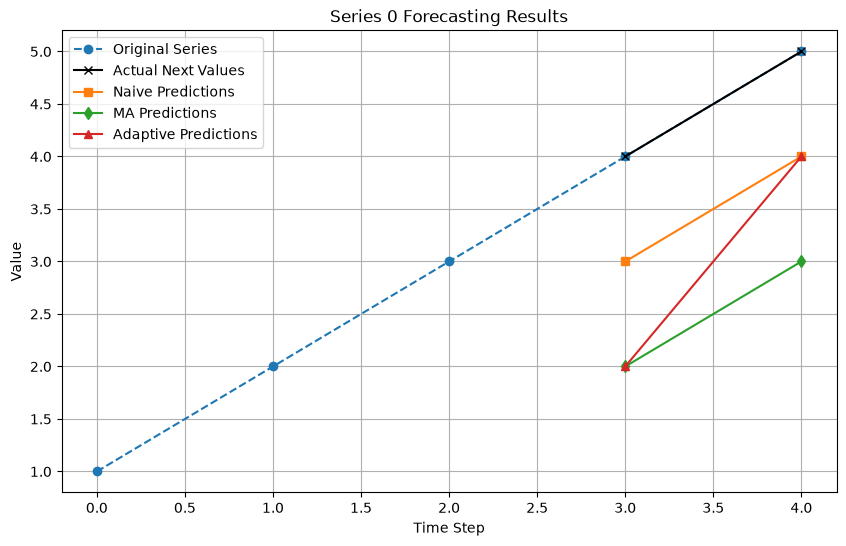


Series ID: 1
  Original Series: [10, 8, 6, 4, 2]
  Actual Values (to predict): [4, 2]
  Naive MSE: 4.0000
  MA MSE: 16.0000
  Adaptive MSE: 4.0000


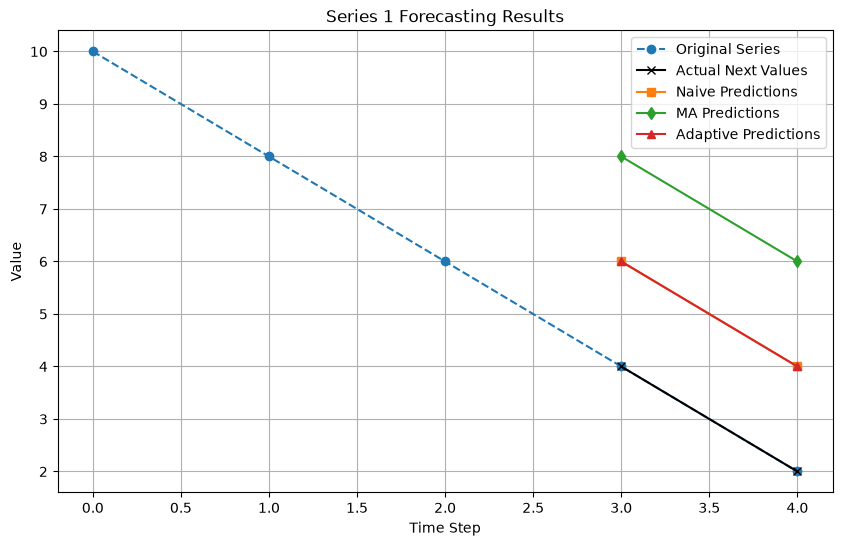


Series ID: 2
  Original Series: [1, 5, 1, 5, 1]
  Actual Values (to predict): [5, 1]
  Naive MSE: 16.0000
  MA MSE: 7.1111
  Adaptive MSE: 7.1111


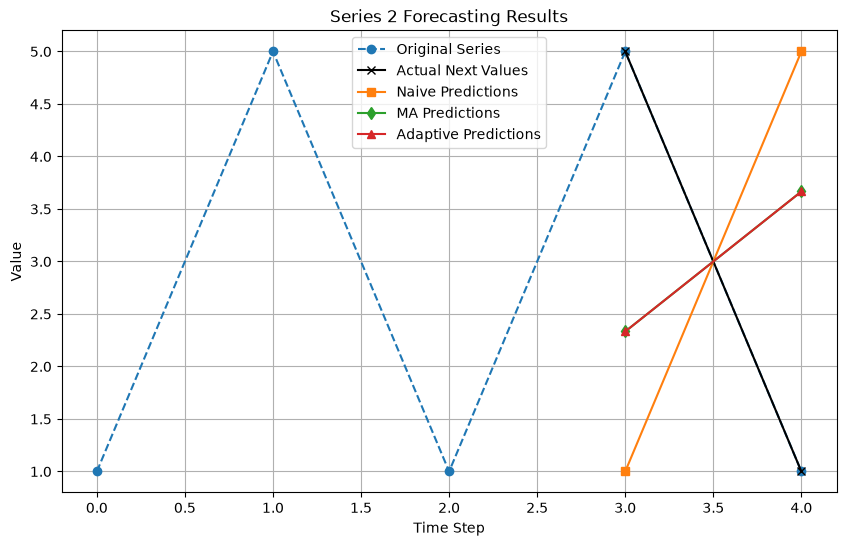

In [10]:
print("### Overall Mean Squared Error (MSE) ###")
for metric, value in overall_metrics.items():
    print(f"{metric}: {value:.4f}")


print("\n### Individual Series Predictions ###")
for r in results:
    series_id = r['series_id']
    series_data = r['series_data']
    actual_values = r['actual_values']
    predictions_naive = r['predictions_naive']
    predictions_ma = r['predictions_ma']
    predictions_adaptive = r['predictions_adaptive']

    print(f"\nSeries ID: {series_id}")
    print(f"  Original Series: {series_data}")
    print(f"  Actual Values (to predict): {actual_values}")
    print(f"  Naive MSE: {r['naive_mse']:.4f}")
    print(f"  MA MSE: {r['ma_mse']:.4f}")
    print(f"  Adaptive MSE: {r['adaptive_mse']:.4f}")

    # Plotting
    plt.figure(figsize=(10, 6))
    full_series_indices = np.arange(len(series_data))
    prediction_indices = np.arange(MIN_LEN_FOR_FORECAST, len(series_data))
    
    plt.plot(full_series_indices, series_data, label='Original Series', marker='o', linestyle='--')
    plt.plot(prediction_indices, actual_values, label='Actual Next Values', marker='x', color='black')
    
    # Filter out None values for plotting predictions
    valid_predictions_naive = [p for p in predictions_naive if p is not None]
    valid_predictions_ma = [p for p in predictions_ma if p is not None]
    valid_predictions_adaptive = [p for p in predictions_adaptive if p is not None]

    # Adjust prediction indices to match valid predictions length
    start_idx = len(series_data) - len(valid_predictions_naive) 
    pred_indices_naive = np.arange(start_idx, len(series_data))
    
    start_idx = len(series_data) - len(valid_predictions_ma) 
    pred_indices_ma = np.arange(start_idx, len(series_data))

    start_idx = len(series_data) - len(valid_predictions_adaptive) 
    pred_indices_adaptive = np.arange(start_idx, len(series_data))

    plt.plot(pred_indices_naive, valid_predictions_naive, label='Naive Predictions', marker='s')
    plt.plot(pred_indices_ma, valid_predictions_ma, label='MA Predictions', marker='d')
    plt.plot(pred_indices_adaptive, valid_predictions_adaptive, label='Adaptive Predictions', marker='^')

    plt.title(f"Series {series_id} Forecasting Results")
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()